In this notebook we build Figure 3(b) of the paper

In [2]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json

from src.plot_style import set_plot_style
from plot_utils import create_figure
from plot_config import get_colors, get_marker

set_plot_style()

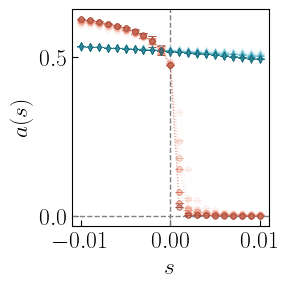

In [3]:
fig, ax = create_figure(5.0, 5.5, margin_cm=2.0)

ax.axhline(y=0, color='grey', linewidth=1, linestyle='--')
ax.axvline(x=0, color='grey', linewidth=1, linestyle='--')

with open('figures_data/activity_data.json', 'r') as f:
    data = json.load(f)

s_range = np.linspace(-0.01, 0.01, 21)
num_sites_range = np.array([4, 6, 8, 10, 20, 40, 60])
V_values = np.array([5.875, 2.0])

for n, L in enumerate(num_sites_range):
    for V in V_values:
        activity_large_values = np.array(data[f"activity_V_{V}_L_{L}_large"])
        activity_small_values = np.array(data[f"activity_V_{V}_L_{L}_small"])
        colors = get_colors(V)
        colors_soft = get_colors(V, alpha=0.3)
        marker = get_marker(V)
        errors = [abs(lv - sv) for lv, sv in zip(activity_large_values, activity_small_values)]
        ax.plot(s_range, activity_large_values, marker=marker, markersize=4.0, markeredgewidth=0.5, ls=':', lw=0.8, c=colors_soft[n], markerfacecolor=colors_soft[n], markeredgecolor=colors[n])
        ax.errorbar(s_range, activity_large_values, yerr=errors, linestyle='None', capsize=3, elinewidth=1, zorder=1, capthick=0.5, lw=0.5, c=colors[n])

ax.set_xlabel(r"$s$", fontsize=17)
ax.set_ylabel(r"$a(s)$", fontsize=17)
ax.set_xticks([-0.01, 0.0, 0.01])
ax.set_yticks([0.0, 0.5])
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=17)

plt.savefig('figures/svg/fig3_b.svg', dpi=300, transparent=True)
plt.savefig('figures/pdf/fig3_b.pdf', dpi=300, transparent=True)
plt.show()